# CranioVision — Ensemble Test-Set Evaluation

Runs the **3-model weighted soft-voting ensemble** on all 30 test cases and computes:

- Mean / std Dice per class (Edema / Enhancing / Necrotic)
- BraTS region Dice (WT / TC / ET)
- Overall mean Dice (primary metric)
- Agreement statistics across all cases
- Per-case ensemble vs per-model comparison
- Volume accuracy across the test set

**This is the single most important evaluation for Phase 2.** The resulting JSON
is what goes into the project report, the README, and any paper.

**Memory-efficient:** Loads 1 model at a time, processes all 30 cases, frees, moves
to next model. Final voting happens on CPU.

**Runtime:** ~50-60 min on GTX 1650 4GB
- Attention U-Net × 30 cases: ~15 min
- SwinUNETR × 30 cases: ~25 min
- nnU-Net × 30 cases: ~15 min
- Ensemble voting + metrics: ~2 min

## 1. Setup

In [1]:
import sys
import json
import gc
import time
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import torch

from src.cranovision.config import (
    MODELS_DIR, OUTPUTS_DIR, CLASS_NAMES, DEVICE, USE_AMP,
)
from src.cranovision.data import get_splits, get_val_transforms
from src.cranovision.inference import (
    load_model,
    weights_from_val_dice,
    compute_region_volumes,
    make_inferer,
)
from src.cranovision.training.metrics import (
    compute_case_dice,
    compute_brats_region_dice,
)

print('✅ Imports ok')

c:\Users\hrana\anaconda3\envs\ml_env_fixed\Lib\site-packages\ignite\handlers\checkpoint.py:17: DeprecationWarning: `TorchScript` support for functional optimizers is deprecated and will be removed in a future PyTorch release. Consider using the `torch.compile` optimizer instead.
  from torch.distributed.optim import ZeroRedundancyOptimizer


✅ Imports ok


In [2]:
# Memory helpers
def free_gpu():
    gc.collect()
    torch.cuda.empty_cache()

def gpu_mem_mb():
    return torch.cuda.memory_allocated() / 1e6 if torch.cuda.is_available() else 0

print(f'Initial GPU memory: {gpu_mem_mb():.1f} MB allocated')

Initial GPU memory: 0.0 MB allocated


In [3]:
# Load val Dice from each model's history JSON (for weighted voting)
def load_val_dice(model_names=('attention_unet', 'swin_unetr', 'nnunet')):
    val_dice = {}
    for name in model_names:
        hist_path = OUTPUTS_DIR / f'{name}_history.json'
        if hist_path.exists():
            with open(hist_path, 'r') as f:
                hist = json.load(f)
            val_dice[name] = float(hist.get('best_dice', 1.0))
        else:
            val_dice[name] = None
    return val_dice

VAL_DICE = load_val_dice()
print('Validation Dice (from history JSONs):')
for name, d in VAL_DICE.items():
    print(f'  {name:<18}: {d}')

Validation Dice (from history JSONs):
  attention_unet    : 0.7642461061477661
  swin_unetr        : 0.8219107985496521
  nnunet            : 0.7562064528465271


In [4]:
# Model registry
MODEL_REGISTRY = {
    'attention_unet': {
        'ckpt': 'attention_unet_best.pth',
        'build_kwargs': {},
    },
    'swin_unetr': {
        'ckpt': 'swin_unetr_best.pth',
        'build_kwargs': {'feature_size': 48, 'use_checkpoint': False},
    },
    'nnunet': {
        'ckpt': 'nnunet_best.pth',
        'build_kwargs': {
            'filters': (32, 64, 128, 256, 320, 320),
            'deep_supervision': False,
        },
    },
}

available_models = {
    name: cfg for name, cfg in MODEL_REGISTRY.items()
    if (MODELS_DIR / cfg['ckpt']).exists()
}
print(f'Available models: {list(available_models.keys())}')
assert len(available_models) >= 2, 'Need at least 2 models for ensemble eval'

# Compute ensemble weights
weight_input = {name: VAL_DICE.get(name) or 1.0 for name in available_models}
weights = weights_from_val_dice(weight_input)
print('\nEnsemble weights:')
for name, w in weights.items():
    print(f'  {name:<18}: {w:.4f}  (val Dice {weight_input[name]:.4f})')

Available models: ['attention_unet', 'swin_unetr', 'nnunet']

Ensemble weights:
  attention_unet    : 0.3263  (val Dice 0.7642)
  swin_unetr        : 0.3509  (val Dice 0.8219)
  nnunet            : 0.3228  (val Dice 0.7562)


In [5]:
# Test set
_, _, test_cases = get_splits()
print(f'\nTest cases: {len(test_cases)}')

Scanning 200 patient folders in BraTS2024_small_dataset/
  Valid cases: 200
Loading existing split from data_split.json
  Train: 140 (70%) | Val: 30 (15%) | Test: 30 (15%)

Test cases: 30


## 2. Stage 1 — Collect softmax probabilities for each model × each case

Loads one model at a time, runs it on all 30 test cases, saves probs per-case on disk to avoid RAM blow-up.

**Why save to disk:** 30 cases × 4 classes × ~180³ voxels × 4 bytes = ~700 MB per model × 3 models = 2.1 GB. Keeping in RAM risks swap. Save per-case `.pt` files, read back for voting.

In [6]:
# Scratch directory for per-case per-model softmax probs
import tempfile
scratch_dir = Path(tempfile.mkdtemp(prefix='ensemble_eval_'))
print(f'Scratch directory: {scratch_dir}')

Scratch directory: C:\Users\hrana\AppData\Local\Temp\ensemble_eval_ph_j1ine


In [7]:
# Preprocess all cases once (shared across models)
print('Preprocessing all test cases (once)...')
transforms = get_val_transforms()
preprocessed = []
for i, case in enumerate(test_cases):
    sample = transforms(case)
    preprocessed.append({
        'case_id': case['case_id'],
        'image': sample['image'],          # CPU
        'label': sample['label'].squeeze(0),  # CPU, shape (D, H, W)
    })
    if (i + 1) % 10 == 0:
        print(f'  {i+1}/{len(test_cases)} cases preprocessed')
print(f'✓ {len(preprocessed)} cases preprocessed on CPU')

Preprocessing all test cases (once)...


monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


  10/30 cases preprocessed
  20/30 cases preprocessed
  30/30 cases preprocessed
✓ 30 cases preprocessed on CPU


In [8]:
# For each model: load, predict on all 30 cases, save probs to disk, free
inferer = make_inferer()
per_model_times = {}

for name, cfg in available_models.items():
    print(f'\n{"=" * 60}')
    print(f'▸ {name}')
    print(f'{"=" * 60}')

    t0 = time.time()
    print(f'Loading {name}...')
    model = load_model(name, MODELS_DIR / cfg['ckpt'], **cfg['build_kwargs'])
    print(f'  GPU after load: {gpu_mem_mb():.1f} MB')
    model.eval()

    for i, item in enumerate(preprocessed):
        case_id = item['case_id']
        with torch.no_grad():
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                image_gpu = item['image'].unsqueeze(0).to(DEVICE)
                logits = inferer(image_gpu, model)
            probs = torch.softmax(logits, dim=1).squeeze(0).cpu().float()

        # Save to disk
        save_path = scratch_dir / f'{name}_{case_id}.pt'
        torch.save(probs, save_path)

        del logits, image_gpu, probs
        if (i + 1) % 5 == 0:
            print(f'  {i+1:2d}/{len(preprocessed)} cases done  |  GPU: {gpu_mem_mb():.1f} MB')

    # Free model
    del model
    free_gpu()
    elapsed = time.time() - t0
    per_model_times[name] = elapsed
    print(f'\n✓ {name} complete in {elapsed/60:.1f} min. GPU: {gpu_mem_mb():.1f} MB')

print(f'\n{"=" * 60}')
print('✅ All predictions collected on disk')
print(f'{"=" * 60}')
for name, t in per_model_times.items():
    print(f'  {name:<18}: {t/60:.1f} min')


▸ attention_unet
Loading attention_unet...
Loading attention_unet from attention_unet_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 97.2 MB


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


   5/30 cases done  |  GPU: 97.2 MB
  10/30 cases done  |  GPU: 97.2 MB
  15/30 cases done  |  GPU: 97.2 MB
  20/30 cases done  |  GPU: 97.2 MB
  25/30 cases done  |  GPU: 97.2 MB
  30/30 cases done  |  GPU: 97.2 MB

✓ attention_unet complete in 7.6 min. GPU: 0.0 MB

▸ swin_unetr
Loading swin_unetr...
Loading swin_unetr from swin_unetr_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 257.3 MB
   5/30 cases done  |  GPU: 290.9 MB
  10/30 cases done  |  GPU: 290.9 MB
  15/30 cases done  |  GPU: 290.9 MB
  20/30 cases done  |  GPU: 290.9 MB
  25/30 cases done  |  GPU: 290.9 MB
  30/30 cases done  |  GPU: 290.9 MB

✓ swin_unetr complete in 52.3 min. GPU: 33.6 MB

▸ nnunet
Loading nnunet...
Loading nnunet from nnunet_best.pth...
  ✓ Loaded. Device: cuda
  GPU after load: 161.6 MB
   5/30 cases done  |  GPU: 161.6 MB
  10/30 cases done  |  GPU: 161.6 MB
  15/30 cases done  |  GPU: 161.6 MB
  20/30 cases done  |  GPU: 161.6 MB
  25/30 cases done  |  GPU: 161.6 MB
  30/30 cases done  |  

## 3. Stage 2 — Ensemble voting + metrics per case

In [12]:
# Accumulators
per_case_ensemble_dice  = []   # list of (edema, enhancing, necrotic)
per_case_ensemble_brats = []   # list of {'WT', 'TC', 'ET'}
per_case_model_dice = {name: [] for name in available_models}
per_case_agreement  = []
per_case_volumes    = []       # ensemble volumes
per_case_gt_volumes = []
per_case_ids        = []

print(f'Running weighted voting on all {len(preprocessed)} cases...\n')

for idx, item in enumerate(preprocessed):
    case_id = item['case_id']
    gt = item['label']

    # Load all models' probs for this case
    weighted_sum = None
    model_preds = {}
    for name in available_models:
        probs = torch.load(scratch_dir / f'{name}_{case_id}.pt', weights_only=False)
        model_preds[name] = probs.argmax(dim=0)

        w = weights[name]
        if weighted_sum is None:
            weighted_sum = w * probs
        else:
            weighted_sum += w * probs

    ensemble_pred = weighted_sum.argmax(dim=0)

    # Per-case metrics
    ens_dice  = compute_case_dice(ensemble_pred, gt)
    ens_brats = compute_brats_region_dice(ensemble_pred, gt)

    per_case_ensemble_dice.append(ens_dice)
    per_case_ensemble_brats.append(ens_brats)
    per_case_volumes.append(compute_region_volumes(ensemble_pred))
    per_case_gt_volumes.append(compute_region_volumes(gt))
    per_case_ids.append(case_id)

    # Per-model metrics
    for name, pred in model_preds.items():
        per_case_model_dice[name].append(compute_case_dice(pred, gt))

    # Agreement
    stacked = torch.stack(list(model_preds.values()))
    mode_pred = torch.mode(stacked, dim=0).values
    agree_count = (stacked == mode_pred.unsqueeze(0)).float().sum(dim=0)
    unanimous_frac = (agree_count == len(model_preds)).float().mean().item()
    per_case_agreement.append(unanimous_frac)

    if (idx + 1) % 5 == 0:
        print(f'  {idx+1:2d}/{len(preprocessed)}: {case_id}  |  '
              f'ens Dice {np.mean(ens_dice):.4f}  |  '
              f'unanimous {unanimous_frac*100:.1f}%')

print(f'\n✅ All {len(preprocessed)} cases voted')

Running weighted voting on all 30 cases...

   5/30: BraTS-GLI-02247-102  |  ens Dice 0.6136  |  unanimous 99.5%
  10/30: BraTS-GLI-02205-102  |  ens Dice 0.9395  |  unanimous 99.5%
  15/30: BraTS-GLI-02063-102  |  ens Dice 0.8733  |  unanimous 99.7%
  20/30: BraTS-GLI-02514-101  |  ens Dice 0.9062  |  unanimous 98.9%
  25/30: BraTS-GLI-02105-105  |  ens Dice 0.8124  |  unanimous 99.7%
  30/30: BraTS-GLI-02245-103  |  ens Dice 0.8989  |  unanimous 99.8%

✅ All 30 cases voted


## 4. Aggregate results

In [13]:
# Per-class aggregates (ensemble)
ens_dice_arr = np.array(per_case_ensemble_dice)   # (N, 3)
per_class_mean = {
    'Edema'          : float(ens_dice_arr[:, 0].mean()),
    'Enhancing tumor': float(ens_dice_arr[:, 1].mean()),
    'Necrotic core'  : float(ens_dice_arr[:, 2].mean()),
}
per_class_std = {
    'Edema'          : float(ens_dice_arr[:, 0].std()),
    'Enhancing tumor': float(ens_dice_arr[:, 1].std()),
    'Necrotic core'  : float(ens_dice_arr[:, 2].std()),
}
overall_mean_dice = float(ens_dice_arr.mean())

# BraTS region aggregates
brats_mean = {k: float(np.mean([b[k] for b in per_case_ensemble_brats])) for k in ('WT', 'TC', 'ET')}
brats_std  = {k: float(np.std ([b[k] for b in per_case_ensemble_brats])) for k in ('WT', 'TC', 'ET')}

# Per-model aggregates (for comparison)
per_model_mean = {}
for name, case_dices in per_case_model_dice.items():
    arr = np.array(case_dices)
    per_model_mean[name] = float(arr.mean())

# Agreement aggregate
mean_agreement = float(np.mean(per_case_agreement))
min_agreement  = float(np.min(per_case_agreement))

# Volume accuracy
volume_errors = []
for pred_v, gt_v in zip(per_case_volumes, per_case_gt_volumes):
    if gt_v['Total tumor'] > 0:
        abs_err = abs(pred_v['Total tumor'] - gt_v['Total tumor'])
        rel_err = abs_err / gt_v['Total tumor']
        volume_errors.append(rel_err)

mean_volume_rel_error = float(np.mean(volume_errors))

print('=' * 60)
print('ENSEMBLE TEST-SET RESULTS')
print('=' * 60)
print(f'Cases: {len(per_case_ids)}')
print()
print('Per-class Dice (ensemble):')
for name in ('Edema', 'Enhancing tumor', 'Necrotic core'):
    print(f'  {name:<20}: {per_class_mean[name]:.4f} ± {per_class_std[name]:.4f}')
print(f'  {"Overall mean":<20}: {overall_mean_dice:.4f}')
print()
print('BraTS regions:')
for r in ('WT', 'TC', 'ET'):
    print(f'  {r:<20}: {brats_mean[r]:.4f} ± {brats_std[r]:.4f}')
print('=' * 60)

ENSEMBLE TEST-SET RESULTS
Cases: 30

Per-class Dice (ensemble):
  Edema               : 0.9063 ± 0.0817
  Enhancing tumor     : 0.6898 ± 0.3299
  Necrotic core       : 0.7598 ± 0.2437
  Overall mean        : 0.7853

BraTS regions:
  WT                  : 0.9142 ± 0.0934
  TC                  : 0.8055 ± 0.2109
  ET                  : 0.6898 ± 0.3299


## 5. Ensemble vs single models — does voting actually help?

In [14]:
print('=' * 60)
print('ENSEMBLE vs SINGLE-MODEL PERFORMANCE')
print('=' * 60)
print(f'{"Model":<22}{"Mean Dice":>12}{"vs Ensemble":>14}')
print('-' * 60)
for name, mean in per_model_mean.items():
    diff = mean - overall_mean_dice
    sign = '+' if diff >= 0 else ''
    display = name.replace('_', ' ').title()
    print(f'  {display:<20}{mean:>12.4f}{sign}{diff:>13.4f}')
print('-' * 60)
print(f'  {"ENSEMBLE":<20}{overall_mean_dice:>12.4f}{"(reference)":>14}')
print()

best_single_name = max(per_model_mean, key=per_model_mean.get)
best_single_mean = per_model_mean[best_single_name]
improvement = overall_mean_dice - best_single_mean
sign = '+' if improvement >= 0 else ''
pct = (improvement / best_single_mean) * 100

print(f'Best single model : {best_single_name} ({best_single_mean:.4f})')
print(f'Ensemble gain     : {sign}{improvement:.4f} Dice ({sign}{pct:.2f}%)')
print()
print(f'Model agreement across cases:')
print(f'  Mean unanimous voxels  : {mean_agreement*100:.2f}%')
print(f'  Min unanimous voxels   : {min_agreement*100:.2f}%  ← hardest case')
print(f'\nVolume accuracy:')
print(f'  Mean rel. error on total tumor: {mean_volume_rel_error*100:.2f}%')
print('=' * 60)

ENSEMBLE vs SINGLE-MODEL PERFORMANCE
Model                    Mean Dice   vs Ensemble
------------------------------------------------------------
  Attention Unet            0.7308      -0.0545
  Swin Unetr                0.7929+       0.0076
  Nnunet                    0.6925      -0.0928
------------------------------------------------------------
  ENSEMBLE                  0.7853   (reference)

Best single model : swin_unetr (0.7929)
Ensemble gain     : -0.0076 Dice (-0.96%)

Model agreement across cases:
  Mean unanimous voxels  : 99.33%
  Min unanimous voxels   : 98.39%  ← hardest case

Volume accuracy:
  Mean rel. error on total tumor: 7.47%


## 6. Visualization — distribution of ensemble Dice across cases

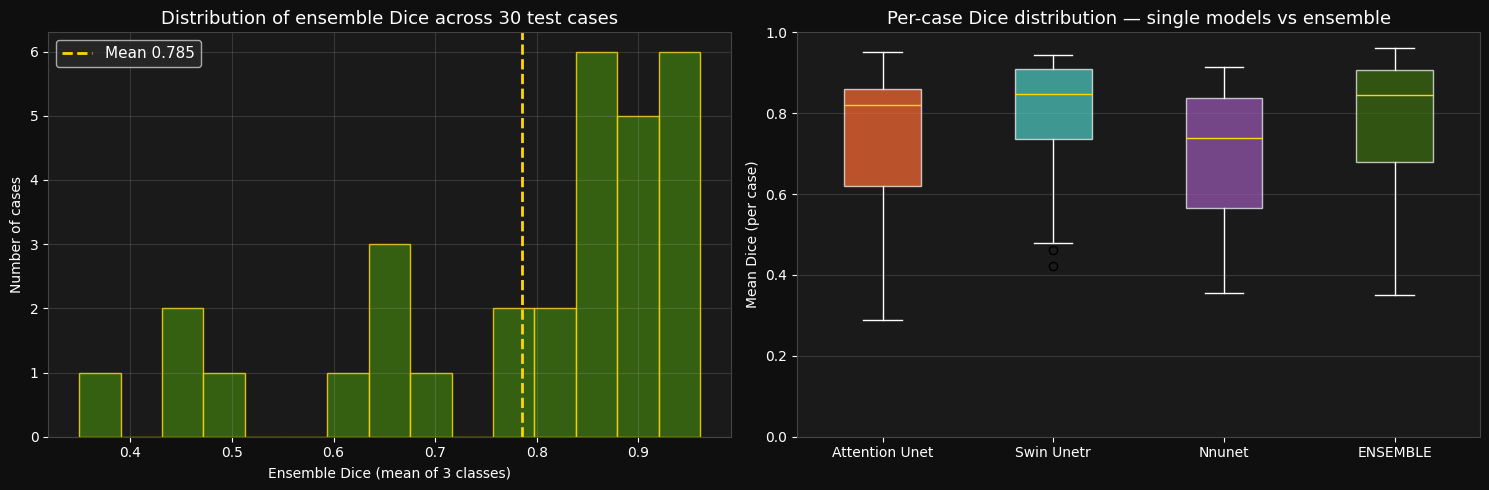


Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\ensemble_test_distribution.png


In [15]:
per_case_overall = ens_dice_arr.mean(axis=1)      # (N,) mean Dice per case

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0f0f0f')

# LEFT: Histogram of ensemble overall Dice
ax = axes[0]
ax.set_facecolor('#1a1a1a')
ax.hist(per_case_overall, bins=15, color='#3B6D11', edgecolor='#FFD700', alpha=0.85)
ax.axvline(overall_mean_dice, color='#FFD700', linewidth=2, linestyle='--',
            label=f'Mean {overall_mean_dice:.3f}')
ax.set_xlabel('Ensemble Dice (mean of 3 classes)', color='white')
ax.set_ylabel('Number of cases', color='white')
ax.set_title('Distribution of ensemble Dice across 30 test cases',
              color='white', fontsize=13)
ax.tick_params(colors='white')
ax.legend(facecolor='#2a2a2a', labelcolor='white', fontsize=11)
ax.grid(alpha=0.2)
for s in ax.spines.values(): s.set_edgecolor('#444')

# RIGHT: Per-model vs ensemble box plot
ax = axes[1]
ax.set_facecolor('#1a1a1a')
model_names_display = [n.replace('_', ' ').title() for n in available_models]
data_boxes = [np.array(per_case_model_dice[n]).mean(axis=1) for n in available_models]
data_boxes.append(per_case_overall)  # ensemble last
labels_boxes = model_names_display + ['ENSEMBLE']
colors_boxes = ['#FF6B35', '#4ECDC4', '#9B59B6', '#3B6D11']

bp = ax.boxplot(data_boxes, labels=labels_boxes, patch_artist=True,
                 boxprops={'color': 'white'}, medianprops={'color': '#FFD700'},
                 whiskerprops={'color': 'white'}, capprops={'color': 'white'})
for patch, color in zip(bp['boxes'], colors_boxes):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_ylabel('Mean Dice (per case)', color='white')
ax.set_title('Per-case Dice distribution — single models vs ensemble',
              color='white', fontsize=13)
ax.tick_params(colors='white')
ax.grid(alpha=0.2, axis='y')
ax.set_ylim(0, 1)
for s in ax.spines.values(): s.set_edgecolor('#444')

plt.tight_layout()
viz_path = OUTPUTS_DIR / 'ensemble_test_distribution.png'
plt.savefig(viz_path, dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()
print(f'\nSaved: {viz_path}')

## 7. Save machine-readable JSON report

In [16]:
report = {
    'n_test_cases': len(per_case_ids),
    'ensemble': {
        'models': list(available_models.keys()),
        'weights': weights,
        'val_dice_reference': weight_input,
    },
    'overall_mean_dice': overall_mean_dice,
    'per_class_mean': per_class_mean,
    'per_class_std': per_class_std,
    'brats_regions': {
        'WT_mean': brats_mean['WT'], 'WT_std': brats_std['WT'],
        'TC_mean': brats_mean['TC'], 'TC_std': brats_std['TC'],
        'ET_mean': brats_mean['ET'], 'ET_std': brats_std['ET'],
    },
    'per_model_mean_dice': per_model_mean,
    'best_single_model': best_single_name,
    'ensemble_gain_over_best_single': improvement,
    'mean_model_agreement': mean_agreement,
    'min_model_agreement': min_agreement,
    'mean_volume_relative_error': mean_volume_rel_error,
    'per_case_ids': per_case_ids,
    'per_case_ensemble_dice': [list(map(float, d)) for d in per_case_ensemble_dice],
    'per_case_ensemble_overall': [float(x) for x in per_case_overall],
    'per_case_unanimous_fraction': per_case_agreement,
}

report_path = OUTPUTS_DIR / 'ensemble_test_results.json'
with open(report_path, 'w') as f:
    json.dump(report, f, indent=2, default=str)

print(f'✅ Saved: {report_path}')
print(f'\nSummary line for the report / README:')
print(f'  Ensemble mean Dice: {overall_mean_dice:.4f} (gain {improvement:+.4f} over {best_single_name})')

✅ Saved: D:\2_ML PROJECTS\30. Brainstorm\CranioVision\outputs\ensemble_test_results.json

Summary line for the report / README:
  Ensemble mean Dice: 0.7853 (gain -0.0076 over swin_unetr)


## 8. Clean up scratch

In [17]:
import shutil
shutil.rmtree(scratch_dir)
print(f'✓ Removed {scratch_dir}')

✓ Removed C:\Users\hrana\AppData\Local\Temp\ensemble_eval_ph_j1ine
